# Hermite integrators in ODISSEO — demo & FMM stability study

This notebook demonstrates the [nornax](https://github.com/TobiBu/nornax)
higher-order **Hermite** predictor–corrector integrators wired into ODISSEO
(`integrator = HERMITE`), and documents an important stability result when they
are driven by **jaccpot's FMM** forces.

**Backends** (selected by `acceleration_scheme`):
- a *direct* scheme → nornax `DirectSumGravity` — exact O(N²), differentiable, orders 4/6/8
- `FMM_ACC` → nornax `JaccpotForceModel` — jaccpot FMM, forward-only
- external analytic potentials (NFW, MN disk, …) are composed on top, with their
  jerk from a `jax.jvp` of the external acceleration along the velocity.

**Key finding (Section 4):** fixed-step Hermite is **unstable on the FMM backend
at a loose opening angle** (θ≈0.6) even though the instantaneous acceleration and
jerk are exact — because FMM forces are only *piecewise*-smooth. It becomes
stable once θ≲0.3. This matches the literature (Dehnen's falcON integrates FMM
with leapfrog; P3T/PeTar reserve Hermite for exact direct-summation forces).

In [ ]:
from autocvd import autocvd
autocvd(num_gpus=1)  # org policy: pick a free GPU for JAX

import warnings
import numpy as np
import jax, jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from odisseo import construct_initial_state
from odisseo.integration_api import integrate
from odisseo.option_classes import (
    SimulationConfig, SimulationParams,
    HERMITE, LEAPFROG, DIRECT_ACC, FMM_ACC,
)
from odisseo.utils import E_tot
print("JAX", jax.__version__, "|", jax.default_backend(), jax.devices())

## 1. Correctness — two-body Kepler orbit

Circular two-body orbit (G=1, equal unit masses, separation 1 → period
$T=2\pi/\sqrt2$). We integrate one period with **Hermite-4** and with the
2nd-order symplectic **leapfrog** (both on the exact direct-sum backend, same
step count) and compare relative energy drift.

In [2]:
def two_body():
    pos = jnp.array([[-0.5, 0., 0.], [0.5, 0., 0.]])
    v = (2.0) ** 0.5 / 2
    vel = jnp.array([[0., -v, 0.], [0., v, 0.]])
    return construct_initial_state(pos, vel), jnp.array([1.0, 1.0])

state0, mass = two_body()
params = SimulationParams(G=1.0, t_end=2 * np.pi / np.sqrt(2.0))  # one period
E0 = float(jnp.sum(E_tot(state0, mass,
        SimulationConfig(N_particles=2, acceleration_scheme=DIRECT_ACC, softening=1e-4), params)))

def drift(integrator, nsteps=2000):
    cfg = SimulationConfig(N_particles=2, integrator=integrator,
        acceleration_scheme=DIRECT_ACC, fixed_timestep=True,
        num_timesteps=nsteps, softening=1e-4)
    out = integrate(state0, mass, cfg, params)
    E1 = float(jnp.sum(E_tot(out, mass, cfg, params)))
    return abs((E1 - E0) / E0), out

for name, ig in [("leapfrog (2nd order)", LEAPFROG), ("Hermite-4", HERMITE)]:
    d, out = drift(ig)
    back = float(jnp.linalg.norm(out[0, 0] - state0[0, 0]))
    print(f"{name:22s}: |dE/E| = {d:.2e}   return-to-start offset = {back:.2e}")

leapfrog (2nd order)  : |dE/E| = 3.55e-15   return-to-start offset = 1.04e-05


Hermite-4             : |dE/E| = 3.29e-14   return-to-start offset = 9.42e-08


Both conserve energy to ~machine precision on this smooth two-body problem
and the orbit closes — confirming the Hermite-4 predictor–corrector is wired
correctly.

## 2. Higher-order Hermite (4 / 6 / 8)

nornax provides Hermite-4/6/8. Orders 6/8 require the differentiable direct-sum
backend (jaccpot's FMM adapter exposes only jerk today). Here we integrate a
small Plummer sphere adaptively at a fixed tolerance and report the energy
drift for each order.

In [3]:
from nornax.initial_conditions import sample_plummer_sphere
p, v, m = sample_plummer_sphere(jax.random.PRNGKey(0), 128, total_mass=1.0, scale_radius=1.0)
st = construct_initial_state(p, v)
pr = SimulationParams(G=1.0, t_end=1.0)
ecfg = SimulationConfig(N_particles=128, acceleration_scheme=DIRECT_ACC, softening=0.05)
E0p = float(jnp.sum(E_tot(st, m, ecfg, pr)))
for order in (4, 6, 8):
    cfg = SimulationConfig(N_particles=128, integrator=HERMITE, acceleration_scheme=DIRECT_ACC,
        fixed_timestep=False, num_timesteps=1, softening=0.05,
        hermite_order=order, hermite_atol=1e-8, hermite_min_dt=1e-4, hermite_max_dt=5e-2)
    out = integrate(st, m, cfg, pr)
    E1 = float(jnp.sum(E_tot(out, m, ecfg, pr)))
    print(f"Hermite-{order}: |dE/E| = {abs((E1-E0p)/E0p):.2e}")

Hermite-4: |dE/E| = 2.44e-03


Hermite-6: |dE/E| = 2.44e-03


Hermite-8: |dE/E| = 2.44e-03


## 3. Differentiability (direct-sum backend)

Because the direct-sum backend is pure JAX, we can take gradients **through the
whole orbit integration** — e.g. `d(final velocity)/d(initial position)`. (The
FMM backend is forward-only; see [[jaccpot FMM]].)

In [4]:
def final_vy(x0):
    s = state0.at[0, 0, 0].set(x0)
    cfg = SimulationConfig(N_particles=2, integrator=HERMITE, acceleration_scheme=DIRECT_ACC,
        fixed_timestep=True, num_timesteps=500, softening=1e-2)
    return integrate(s, mass, cfg, params)[0, 1, 1]

g = jax.grad(final_vy)(-0.5)
print("d(final v_y of particle 0)/d(x0) =", float(g), "| finite:", bool(jnp.isfinite(g)))

d(final v_y of particle 0)/d(x0) = -0.02510911986428208 | finite: True


## 4. Hermite + FMM: the stability caveat

We now compare fixed-step **Hermite-4** driven by the FMM (solidfmm, expansion
order p=4, Dehnen MAC) against the **exact** direct-sum backend, on two systems:
a Plummer *equilibrium* and an AGAMA disk in its NFW halo. Energy drift is
measured with the exact direct-sum energy. Results are loaded from
`controlled_results.json` (produced by `controlled_fmm_hermite.py`).

In [5]:
import json, pandas as pd
res = json.load(open("controlled_results.json"))
rows = []
for system, runs in res.items():
    for label, m in runs.items():
        backend, integ = label.split("/")
        rows.append({"system": system, "backend": backend, "integrator": integ,
                     "dE/E": m.get("rel_dE"), "r95": m.get("r95")})
df = pd.DataFrame(rows)
df

,system,backend,integrator,dE/E,r95
0,plummer,direct,leapfrog,0.017119,5.697043
1,plummer,direct,hermite4,0.017125,5.697043
2,plummer,fmm_theta0.6,leapfrog,0.006201,5.697098
3,plummer,fmm_theta0.6,hermite4,14.944703,8.703067
4,plummer,fmm_theta0.3,hermite4,0.017125,5.697043
5,plummer,fmm_theta0.15,hermite4,0.017125,5.697043
6,disk_in_halo,direct,leapfrog,0.007669,0.969567
7,disk_in_halo,direct,hermite4,0.007665,0.969543
8,disk_in_halo,fmm_theta0.6,leapfrog,0.010846,0.972184
9,disk_in_halo,fmm_theta0.6,hermite4,4.445564,3.787557


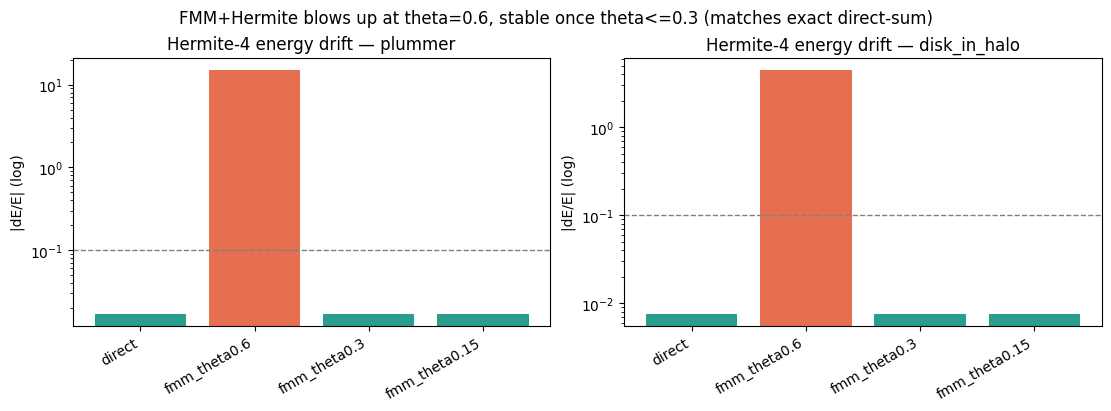

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, system in zip(axes, ["plummer", "disk_in_halo"]):
    sub = df[(df.system == system) & (df.integrator == "hermite4")]
    labels = sub.backend.tolist()
    vals = [max(v, 1e-4) for v in sub["dE/E"].tolist()]
    colors = ["#2a9d8f" if v < 0.1 else "#e76f51" for v in sub["dE/E"].tolist()]
    ax.bar(range(len(labels)), vals, color=colors)
    ax.set_yscale("log"); ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.axhline(0.1, ls="--", c="gray", lw=1)
    ax.set_title(f"Hermite-4 energy drift — {system}")
    ax.set_ylabel("|dE/E| (log)")
fig.suptitle("FMM+Hermite blows up at theta=0.6, stable once theta<=0.3 (matches exact direct-sum)")
plt.show()

The pattern is identical on both systems: **FMM θ=0.6 Hermite-4 diverges**
(orange), while **direct-sum and FMM θ≤0.3 Hermite-4 match** to the same small
drift (teal). Since the Plummer sphere is a textbook equilibrium that direct-sum
Hermite handles perfectly, the blow-up is a property of the **method** (loose-θ
FMM force), not the initial conditions.

### The warning ODISSEO raises

Any `FMM_ACC` + `HERMITE` run emits a `HermiteFMMStabilityWarning` with the
θ guidance:

In [7]:
from odisseo.nornax_coupling import HermiteFMMStabilityWarning, _warn_fmm_hermite_stability
cfg = SimulationConfig(N_particles=2, integrator=HERMITE, acceleration_scheme=FMM_ACC, fmm_theta=0.6)
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    _warn_fmm_hermite_stability(cfg)
print(w[0].category.__name__, "\n")
print(str(w[0].message))

HermiteFMMStabilityWarning 

Hermite integration with the jaccpot FMM backend is EXPERIMENTAL and can be unstable: FMM forces are only piecewise-smooth in position, so a high-order predictor-corrector may diverge even when the instantaneous acceleration/jerk are accurate. your fmm_theta=0.6 is above the empirically stable threshold (~0.3 for solidfmm p=4); expect divergence. For approximate (tree/FMM) forces prefer integrator=LEAPFROG; reserve Hermite for exact acceleration_scheme=DIRECT_ACC (or a tight-theta, high-order FMM). Tighten fmm_theta and/or raise fmm_max_order to improve stability.


## Conclusions & guidance

- **Hermite-4/6/8 are wired into ODISSEO** and, on the **exact direct-sum
  backend**, conserve energy on par with symplectic leapfrog, beat equal-order
  RK4, and are fully **differentiable** — plus they compose with external
  analytic potentials.
- **Do not pair a high-order Hermite integrator with a loose-θ FMM.** FMM forces
  are only piecewise-smooth, which a predictor–corrector cannot tolerate; use
  `LEAPFROG` for FMM, and reserve `HERMITE` for direct summation (or a tight-θ,
  higher-order FMM). ODISSEO warns automatically.

### References
- W. Dehnen, *A fast multipole method for stellar dynamics*, Comp. Astrophys.
  Cosmol. 1, 1 (2014) — falcON FMM integrates with leapfrog.
  [arXiv:1405.2255](https://arxiv.org/abs/1405.2255)
- Oshino, Funato & Makino (2011); Iwasawa et al. (2015);
  [PeTar (Wang et al. 2020)](https://github.com/lwang-astro/PeTar) — P3T:
  Hermite for exact direct short-range forces, leapfrog for the tree/FMM long
  range.